# Downloading the data and computing log-returns

In [3]:
# Requirements:
#   pip install yfinance pandas numpy matplotlib statsmodels scipy
#

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm, probplot

# ----------------------------
# 1) Download Apple data
# ----------------------------
ticker = "AAPL"
start_date = "2020-01-01"
end_date   = "2025-12-31"


df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust= False,
)

# ---- FIX: flatten columns if MultiIndex ----
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep Close prices
df = df.dropna(subset=["Close"])
price = df["Close"].astype(float)

#  Log-returns

log_ret = np.log(price).diff().dropna()


# Log-Returns + Histogram

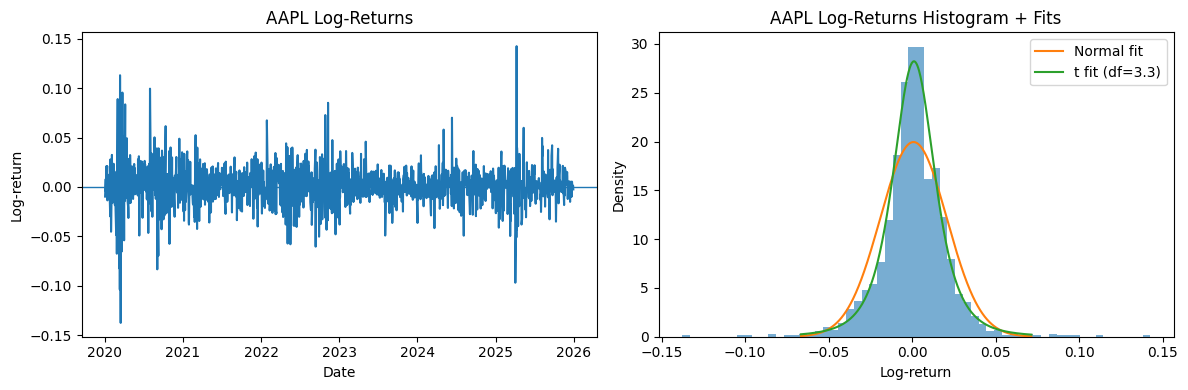

Normal fit:
  mean (mu)   = 0.000857
  std  (sig)  = 0.019999

Student-t fit:
  df          = 3.286
  loc         = 0.001135
  scale       = 0.013116


In [6]:
from scipy.stats import norm, t
# 1) Side-by-side log-returns plot and histogram with Normal and t fit

# Fit Normal
mu_hat, sigma_hat = np.mean(log_ret ), np.std(log_ret , ddof=1)

# Fit Student-t (df, loc, scale)
df_t, loc_t, scale_t = t.fit(log_ret )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (A) Time series of log-returns
axes[0].plot(log_ret.index, log_ret.values)
axes[0].axhline(0, linewidth=1)
axes[0].set_title(f"{ticker} Log-Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Log-return")

# (B) Histogram + fitted PDFs
axes[1].hist(log_ret , bins=60, density=True, alpha=0.6)
xmin, xmax = np.percentile(x, [0.5, 99.5])
grid = np.linspace(xmin, xmax, 500)

axes[1].plot(grid, norm.pdf(grid, loc=mu_hat, scale=sigma_hat), label="Normal fit")
axes[1].plot(grid, t.pdf(grid, df=df_t, loc=loc_t, scale=scale_t), label=f"t fit (df={df_t:.1f})")

axes[1].set_title(f"{ticker} Log-Returns Histogram + Fits")
axes[1].set_xlabel("Log-return")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("hist_apple.png")
plt.show()

print("Normal fit:")
print(f"  mean (mu)   = {mu_hat:.6f}")
print(f"  std  (sig)  = {sigma_hat:.6f}")

print("\nStudent-t fit:")
print(f"  df          = {df_t:.3f}")
print(f"  loc         = {loc_t:.6f}")
print(f"  scale       = {scale_t:.6f}")


# Time Series Plots

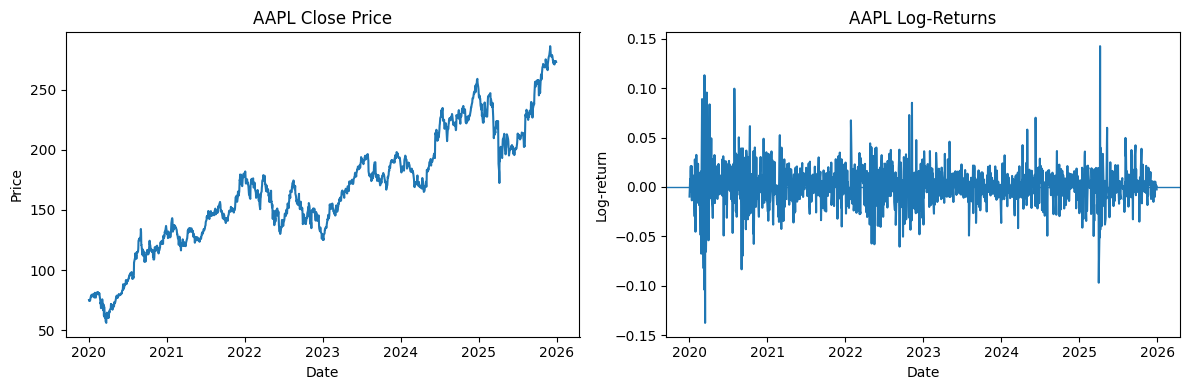

In [8]:
# 2) Side-by-side time series plot of prices and log-returns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(price.index, price.values)
axes[0].set_title(f"{ticker} Close Price")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Price")

axes[1].plot(log_ret.index, log_ret.values)
axes[1].axhline(0, linewidth=1)
axes[1].set_title(f"{ticker} Log-Returns")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log-return")

plt.tight_layout()
plt.savefig("time_plots.png")
plt.show()


# Test of Stationarity

In [10]:
# 3) ADF test of log-returns with verbose output
from statsmodels.tsa.stattools import adfuller

result = adfuller(log_ret)
adf_stat, p_value, used_lag, n_obs, crit_vals, icbest = result

print("ADF Test (Augmented Dickey-Fuller) on Log-Returns")
print("-" * 55)
print(f"ADF Statistic:     {adf_stat:.6f}")
print(f"p-value:           {p_value:.6g}")
print("Critical Values:")
for k, v in crit_vals.items():
    print(f"  {k:>4}: {v:.6f}")

alpha = 0.05
print("-" * 55)
if p_value < alpha:
    print(f"Decision @ {alpha:.0%}: Reject H0 (unit root). The series is likely STATIONARY.")
else:
    print(f"Decision @ {alpha:.0%}: Fail to reject H0 (unit root). The series may be NON-STATIONARY.")


ADF Test (Augmented Dickey-Fuller) on Log-Returns
-------------------------------------------------------
ADF Statistic:     -13.001827
p-value:           2.6774e-24
Critical Values:
    1%: -3.434726
    5%: -2.863473
   10%: -2.567799
-------------------------------------------------------
Decision @ 5%: Reject H0 (unit root). The series is likely STATIONARY.


# Autocorrelations

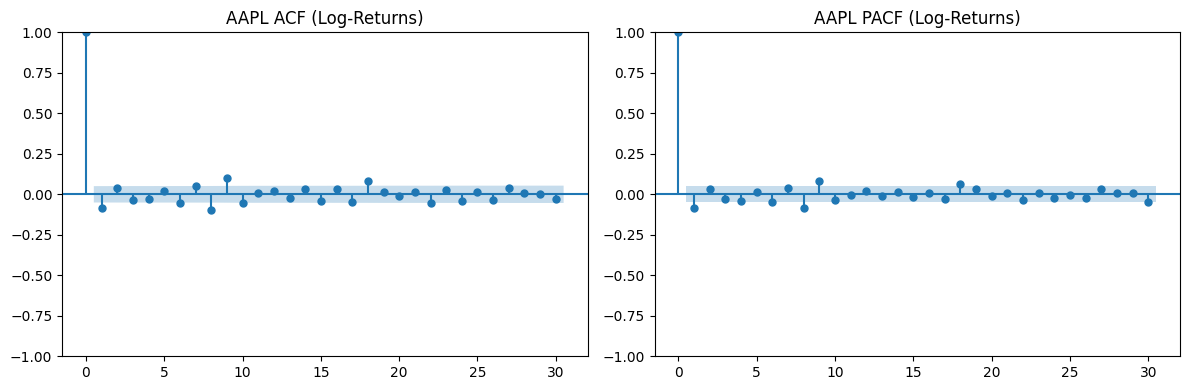

In [13]:
# 4) Side-by-side ACF and PACF plots of log-returns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(log_ret.values, lags=30, ax=axes[0])
axes[0].set_title(f"{ticker} ACF (Log-Returns)")

plot_pacf(log_ret.values, lags=30, ax=axes[1], method="ywm")
axes[1].set_title(f"{ticker} PACF (Log-Returns)")

plt.tight_layout()
plt.savefig("auto.png")
plt.show()


# Ljung-Box Test

In [14]:
# 5) Ljung-Box test with k=10, verbose output
from statsmodels.stats.diagnostic import acorr_ljungbox
k = 10
lb = acorr_ljungbox(log_ret.values, lags=[k], return_df=True)

lb_stat = float(lb["lb_stat"].iloc[0])
lb_pval = float(lb["lb_pvalue"].iloc[0])

print("Ljung–Box Test on Log-Returns")
print("-" * 55)
print(f"LB statistic:      {lb_stat:.6f}")
print(f"p-value:           {lb_pval:.6g}")
print("-" * 55)

alpha = 0.05
if lb_pval < alpha:
    print(f"Decision @ {alpha:.0%}: Reject H0. Evidence of autocorrelation up to lag {k}.")
else:
    print(f"Decision @ {alpha:.0%}: Fail to reject H0. No strong evidence of autocorrelation up to lag {k}.")


Ljung–Box Test on Log-Returns
-------------------------------------------------------
LB statistic:      59.007291
p-value:           5.58268e-09
-------------------------------------------------------
Decision @ 5%: Reject H0. Evidence of autocorrelation up to lag 10.


# Fitting AR(1) Model

In [ ]:
!pip install arch

In [27]:
from arch import arch_model
# ---- AR(1) with constant variance ----
model = arch_model(
    100*log_ret,
    mean="AR",
    lags=1,
    vol="Constant",
    dist="normal"
)
res = model.fit(disp="off")
print(res.summary())


                     AR - Constant Variance Model Results                     
Dep. Variable:                  Close   R-squared:                       0.007
Mean Model:                        AR   Adj. R-squared:                  0.006
Vol Model:          Constant Variance   Log-Likelihood:               -3173.09
Distribution:                  Normal   AIC:                           6352.18
Method:            Maximum Likelihood   BIC:                           6368.13
                                        No. Observations:                 1505
Date:                Tue, Feb 03 2026   Df Residuals:                     1503
Time:                        11:41:59   Df Model:                            2
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.0937  5.195e-02      1.803  7.136e-02 [-8.14

# Diagnostic plots vs White Noise

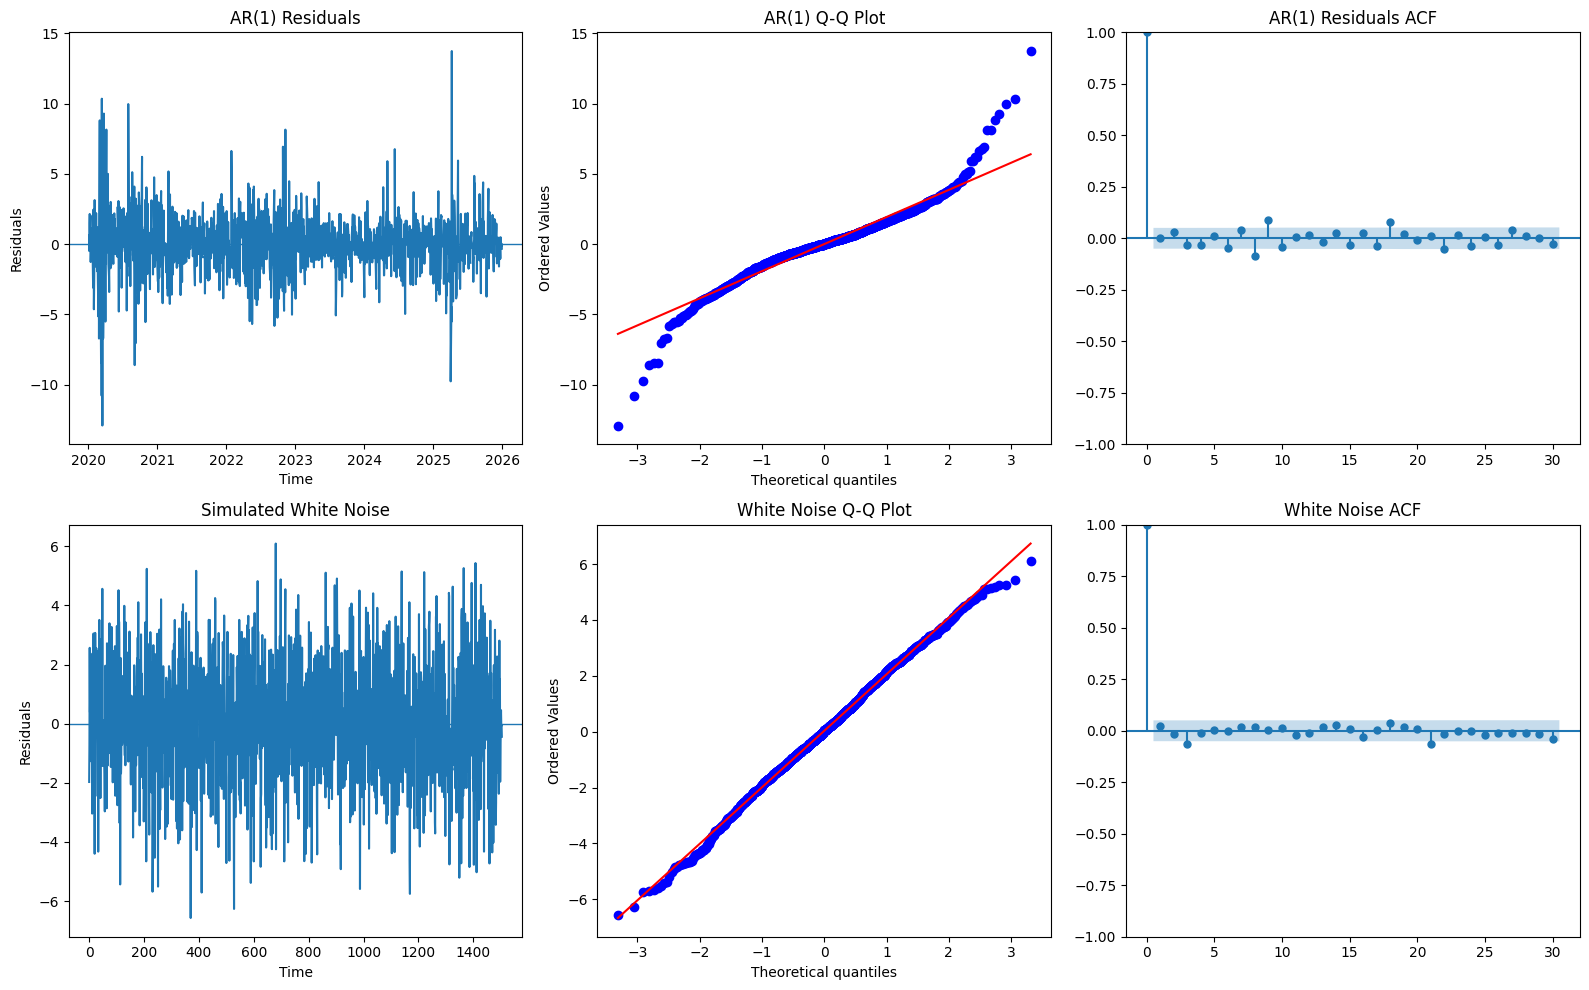

In [22]:
# --- AR(1) residual diagnostics vs simulated white noise ---
# Assumes you already have:
#   - log_ret (pd.Series)
#   - res = fitted result from arch_model(..., mean="AR", lags=1, vol="Constant")

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot, norm
from statsmodels.graphics.tsaplots import plot_acf

# ----------------------------
# 1) Get residuals from AR(1)
# ----------------------------
# arch returns residuals aligned with the input series (after dropping initial lags)
ar_resid = res.resid.dropna()
idx = ar_resid.index

# innovation variance estimate from the fitted model (constant variance)
sigma2_hat = float(res.params["sigma2"])
sigma_hat = np.sqrt(sigma2_hat)

# ----------------------------
# 2) Simulate white noise with same variance and same length
# ----------------------------
rng = np.random.default_rng(123)  # reproducible
wn = rng.normal(loc=0.0, scale=sigma_hat, size=len(ar_resid))

# ----------------------------
# 3) Build the 2x3 panel figure
# ----------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1, Col 1: AR(1) residuals (time series)
axes[0, 0].plot(idx, ar_resid.values)
axes[0, 0].axhline(0, linewidth=1)
axes[0, 0].set_title("AR(1) Residuals")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Residuals")

# Row 1, Col 2: AR(1) residuals Q-Q plot (Normal)
probplot(ar_resid.values, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("AR(1) Q-Q Plot")
# Make the reference line red (to match your old plot style)
# probplot draws two lines; the last one is usually the fit line
if len(axes[0, 1].lines) >= 2:
    axes[0, 1].lines[1].set_color("red")

# Row 1, Col 3: AR(1) residuals ACF
plot_acf(ar_resid.values, lags=30, ax=axes[0, 2])
axes[0, 2].set_title("AR(1) Residuals ACF")

# Row 2, Col 1: Simulated white noise (time series)
axes[1, 0].plot(np.arange(len(wn)), wn)
axes[1, 0].axhline(0, linewidth=1)
axes[1, 0].set_title("Simulated White Noise")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Residuals")

# Row 2, Col 2: White noise Q-Q plot (Normal)
probplot(wn, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("White Noise Q-Q Plot")
if len(axes[1, 1].lines) >= 2:
    axes[1, 1].lines[1].set_color("red")

# Row 2, Col 3: White noise ACF
plot_acf(wn, lags=30, ax=axes[1, 2])
axes[1, 2].set_title("White Noise ACF")

plt.tight_layout()
plt.savefig("diag_normal.png")
plt.show()


# AR(1) with T-distribution

In [26]:
from arch import arch_model
# ---- AR(1) with constant variance ----
model_t = arch_model(
    100*log_ret,
    mean="AR",
    lags=1,
    vol="Constant",
    dist="t"
)
res_t = model_t.fit(disp="off")
print(res.summary())


                     AR - Constant Variance Model Results                     
Dep. Variable:                  Close   R-squared:                       0.007
Mean Model:                        AR   Adj. R-squared:                  0.006
Vol Model:          Constant Variance   Log-Likelihood:               -3173.09
Distribution:                  Normal   AIC:                           6352.18
Method:            Maximum Likelihood   BIC:                           6368.13
                                        No. Observations:                 1505
Date:                Tue, Feb 03 2026   Df Residuals:                     1503
Time:                        11:39:07   Df Model:                            2
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.0937  5.195e-02      1.803  7.136e-02 [-8.14

# Comparison of Diagnostics

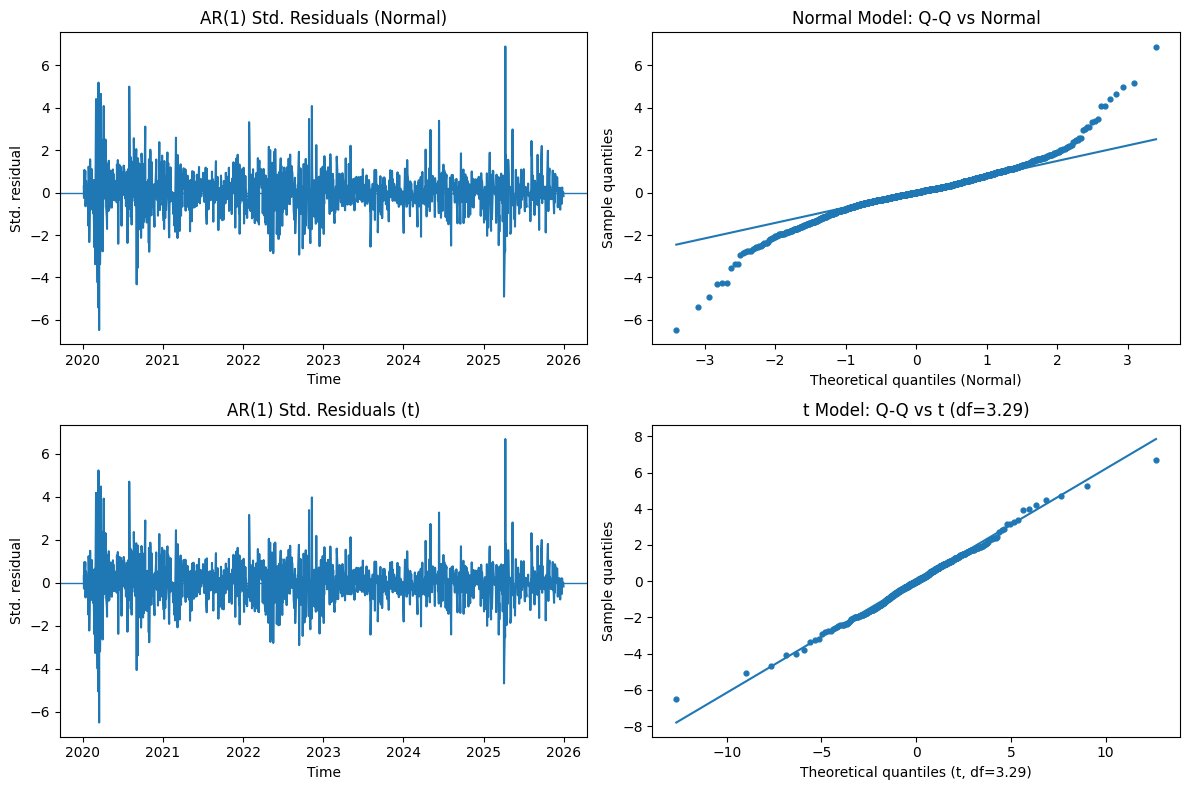

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t


# Use standardized residuals (these should match Normal / t assumptions)
e_n = res.std_resid.dropna()
e_t = res_t.std_resid.dropna()

# Estimated df for the t model (arch calls it "nu")
nu_hat = float(res_t.params["nu"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ----------------------------
# (1) Normal model residuals: time series
# ----------------------------
axes[0, 0].plot(e_n.index, e_n.values)
axes[0, 0].axhline(0, linewidth=1)
axes[0, 0].set_title("AR(1) Std. Residuals (Normal)")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Std. residual")

# ----------------------------
# (2) Normal Q-Q plot
# ----------------------------
x = np.sort(e_n.values)
n = len(x)
p = (np.arange(1, n + 1) - 0.5) / n
q = norm.ppf(p)

axes[0, 1].scatter(q, x, s=12)
# reference line via quartiles (robust)
xq1, xq3 = np.percentile(x, [25, 75])
qq1, qq3 = np.percentile(q, [25, 75])
slope = (xq3 - xq1) / (qq3 - qq1)
intercept = xq1 - slope * qq1
xx = np.array([q.min(), q.max()])
axes[0, 1].plot(xx, intercept + slope * xx)

axes[0, 1].set_title("Normal Model: Q-Q vs Normal")
axes[0, 1].set_xlabel("Theoretical quantiles (Normal)")
axes[0, 1].set_ylabel("Sample quantiles")

# ----------------------------
# (3) t model residuals: time series
# ----------------------------
axes[1, 0].plot(e_t.index, e_t.values)
axes[1, 0].axhline(0, linewidth=1)
axes[1, 0].set_title("AR(1) Std. Residuals (t)")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Std. residual")

# ----------------------------
# (4) t Q-Q plot (with estimated df)
# ----------------------------
x = np.sort(e_t.values)
n = len(x)
p = (np.arange(1, n + 1) - 0.5) / n
q = t.ppf(p, df=nu_hat)

axes[1, 1].scatter(q, x, s=12)
# reference line via quartiles
xq1, xq3 = np.percentile(x, [25, 75])
qq1, qq3 = np.percentile(q, [25, 75])
slope = (xq3 - xq1) / (qq3 - qq1)
intercept = xq1 - slope * qq1
xx = np.array([q.min(), q.max()])
axes[1, 1].plot(xx, intercept + slope * xx)

axes[1, 1].set_title(f"t Model: Q-Q vs t (df={nu_hat:.2f})")
axes[1, 1].set_xlabel(f"Theoretical quantiles (t, df={nu_hat:.2f})")
axes[1, 1].set_ylabel("Sample quantiles")

plt.tight_layout()
plt.savefig("comp.png")
plt.show()


Information criteria (AR(p), t innovations, Constant variance)
            AIC          BIC
p                           
1   6065.931965  6087.198157
2   6064.639869  6091.219287
3   6063.737060  6095.628371
4   6061.330137  6098.532006
5   6058.131158  6100.642253
6   6057.544250  6105.363233
7   6054.655176  6107.780711
8   6052.730948  6111.161695
9   6049.628498  6113.363119
10  6044.431380  6113.468532
11  6041.989492  6116.327833
12  6041.074484  6120.712669
13  6038.820265  6123.756950
14  6037.042831  6127.276669
15  6034.436307  6129.965948
16  6029.114429  6129.938525
17  6017.528988  6123.646189
18  6012.612599  6124.021552
19  6012.013327  6128.712678
20  6004.677367  6126.665761

Best lag order:
  AIC minimizes at p = 20  (AIC = 6004.677)
  BIC minimizes at p = 1  (BIC = 6087.198)


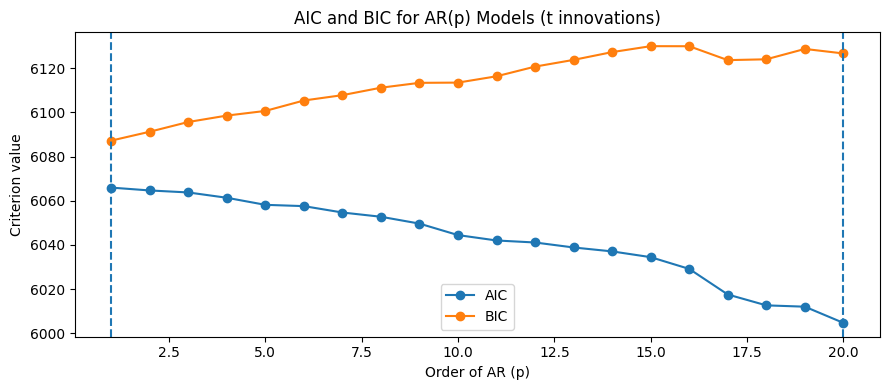

In [35]:
pmax = 20

# ----------------------------
# 1) Fit AR(p) with t-dist for p=1..20, store AIC/BIC
# ----------------------------
rows = []
results = {}

for p in range(1, pmax + 1):
    m = arch_model(
        100*log_ret,
        mean="AR",
        lags=p,
        vol="Constant",
        dist="t"
    )
    r = m.fit(disp="off")
    results[p] = r
    rows.append({"p": p, "AIC": r.aic, "BIC": r.bic})

ic = pd.DataFrame(rows).set_index("p")

# Best lags
best_aic_p = int(ic["AIC"].idxmin())
best_bic_p = int(ic["BIC"].idxmin())

print("Information criteria (AR(p), t innovations, Constant variance)")
print(ic)
print("\nBest lag order:")
print(f"  AIC minimizes at p = {best_aic_p}  (AIC = {ic.loc[best_aic_p,'AIC']:.3f})")
print(f"  BIC minimizes at p = {best_bic_p}  (BIC = {ic.loc[best_bic_p,'BIC']:.3f})")

# ----------------------------
# 2) Plot AIC and BIC
# ----------------------------
plt.figure(figsize=(9, 4))
plt.plot(ic.index, ic["AIC"], marker="o", label="AIC")
plt.plot(ic.index, ic["BIC"], marker="o", label="BIC")

# Mark minima
plt.axvline(best_aic_p, linestyle="--")
plt.axvline(best_bic_p, linestyle="--")

plt.title("AIC and BIC for AR(p) Models (t innovations)")
plt.xlabel("Order of AR (p)")
plt.ylabel("Criterion value")
plt.legend()
plt.tight_layout()
plt.savefig("aics.png")
plt.show()


# Forecasts

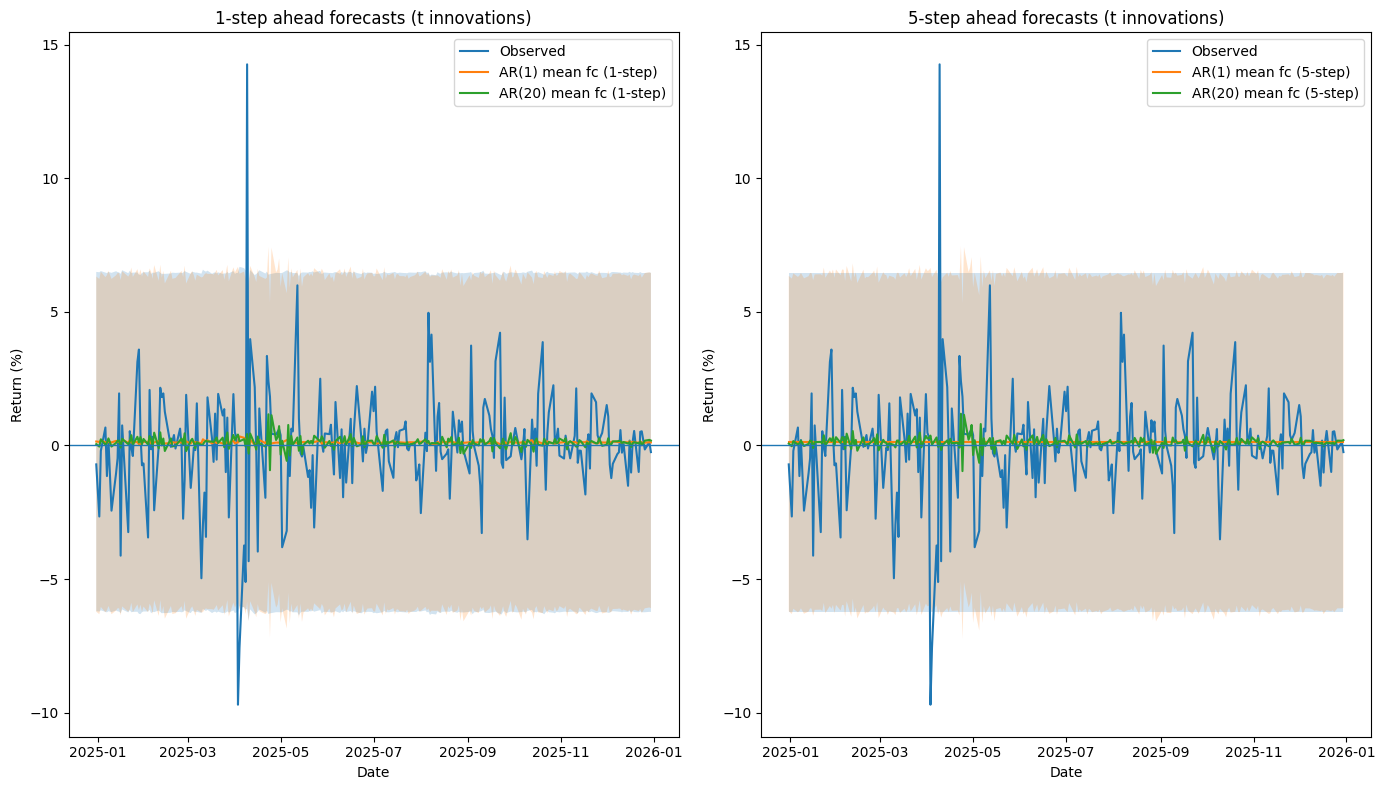

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from arch import arch_model

# Data (keep intercept in the model; no demeaning)
y = (100 * log_ret).dropna()

# Fit AR(1) and AR(20) with t innovations, constant variance
res1  = arch_model(y, mean="AR", lags=1,  vol="Constant", dist="t").fit(disp="off")
res20 = arch_model(y, mean="AR", lags=20, vol="Constant", dist="t").fit(disp="off")

# Choose a subset to plot (last N points)
N = 250
y_sub = y.iloc[-N:]

# Start forecasts a bit earlier so 5-step forecasts cover the plotted window
start_pos = max(0, len(y) - N - 10)

# Rolling forecasts up to horizon 5
fc1  = res1.forecast(horizon=5, start=start_pos, reindex=True)
fc20 = res20.forecast(horizon=5, start=start_pos, reindex=True)

# Extract mean forecasts
m1_h1  = fc1.mean["h.1"].shift(1)
m1_h5  = fc1.mean["h.5"].shift(5)

m20_h1 = fc20.mean["h.1"].shift(1)
m20_h5 = fc20.mean["h.5"].shift(5)

# Extract forecast variances (constant variance model -> same idea, but arch returns it cleanly)
v1_h1  = fc1.variance["h.1"].shift(1)
v1_h5  = fc1.variance["h.5"].shift(5)

v20_h1 = fc20.variance["h.1"].shift(1)
v20_h5 = fc20.variance["h.5"].shift(5)

# t-quantiles for 95% prediction intervals using estimated df (nu)
nu1  = float(res1.params["nu"])
nu20 = float(res20.params["nu"])
q1   = t.ppf(0.975, df=nu1)
q20  = t.ppf(0.975, df=nu20)

# Build PI bands
lo1_h1,  hi1_h1  = m1_h1  - q1*np.sqrt(v1_h1),   m1_h1  + q1*np.sqrt(v1_h1)
lo1_h5,  hi1_h5  = m1_h5  - q1*np.sqrt(v1_h5),   m1_h5  + q1*np.sqrt(v1_h5)

lo20_h1, hi20_h1 = m20_h1 - q20*np.sqrt(v20_h1), m20_h1 + q20*np.sqrt(v20_h1)
lo20_h5, hi20_h5 = m20_h5 - q20*np.sqrt(v20_h5), m20_h5 + q20*np.sqrt(v20_h5)

# Restrict everything to the plotting window
idx = y_sub.index

m1_h1, lo1_h1, hi1_h1       = m1_h1.loc[idx],  lo1_h1.loc[idx],  hi1_h1.loc[idx]
m20_h1, lo20_h1, hi20_h1    = m20_h1.loc[idx], lo20_h1.loc[idx], hi20_h1.loc[idx]

m1_h5, lo1_h5, hi1_h5       = m1_h5.loc[idx],  lo1_h5.loc[idx],  hi1_h5.loc[idx]
m20_h5, lo20_h5, hi20_h5    = m20_h5.loc[idx], lo20_h5.loc[idx], hi20_h5.loc[idx]

# Plot: 1-step (left), 5-step (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# ---- 1-step ahead ----
axes[0].plot(idx, y_sub.values, label="Observed")
axes[0].plot(idx, m1_h1.values, label="AR(1) mean fc (1-step)")
axes[0].fill_between(idx, lo1_h1.values, hi1_h1.values, alpha=0.2)

axes[0].plot(idx, m20_h1.values, label="AR(20) mean fc (1-step)")
axes[0].fill_between(idx, lo20_h1.values, hi20_h1.values, alpha=0.2)

axes[0].axhline(0, linewidth=1)
axes[0].set_title("1-step ahead forecasts (t innovations)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Return (%)")
axes[0].legend()

# ---- 5-step ahead ----
axes[1].plot(idx, y_sub.values, label="Observed")
axes[1].plot(idx, m1_h5.values, label="AR(1) mean fc (5-step)")
axes[1].fill_between(idx, lo1_h5.values, hi1_h5.values, alpha=0.2)

axes[1].plot(idx, m20_h5.values, label="AR(20) mean fc (5-step)")
axes[1].fill_between(idx, lo20_h5.values, hi20_h5.values, alpha=0.2)

axes[1].axhline(0, linewidth=1)
axes[1].set_title("5-step ahead forecasts (t innovations)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Return (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("forecast.png")
plt.show()


In [40]:
# Realized values aligned with forecasts
y_h1 = y.shift(-1).loc[idx]   # realized at t+1
y_h5 = y.shift(-5).loc[idx]   # realized at t+5

# Forecast errors
err1_h1  = y_h1 - m1_h1
err20_h1 = y_h1 - m20_h1

err1_h5  = y_h5 - m1_h5
err20_h5 = y_h5 - m20_h5

def rmse(x):
    return np.sqrt(np.nanmean(x**2))

def mae(x):
    return np.nanmean(np.abs(x))

print("Forecast accuracy (out-of-sample)")
print("-" * 50)

print("1-step ahead:")
print(f"  AR(1)  RMSE = {rmse(err1_h1):.4f},  MAE = {mae(err1_h1):.4f}")
print(f"  AR(20) RMSE = {rmse(err20_h1):.4f},  MAE = {mae(err20_h1):.4f}")

print("\n5-step ahead:")
print(f"  AR(1)  RMSE = {rmse(err1_h5):.4f},  MAE = {mae(err1_h5):.4f}")
print(f"  AR(20) RMSE = {rmse(err20_h5):.4f},  MAE = {mae(err20_h5):.4f}")


Forecast accuracy (out-of-sample)
--------------------------------------------------
1-step ahead:
  AR(1)  RMSE = 2.0360,  MAE = 1.2839
  AR(20) RMSE = 2.0506,  MAE = 1.2848

5-step ahead:
  AR(1)  RMSE = 2.0360,  MAE = 1.2802
  AR(20) RMSE = 2.0686,  MAE = 1.3060
